Tree

In [3]:
import pandas as pd
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df=pd.read_csv('kyphosis.csv')

In [6]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


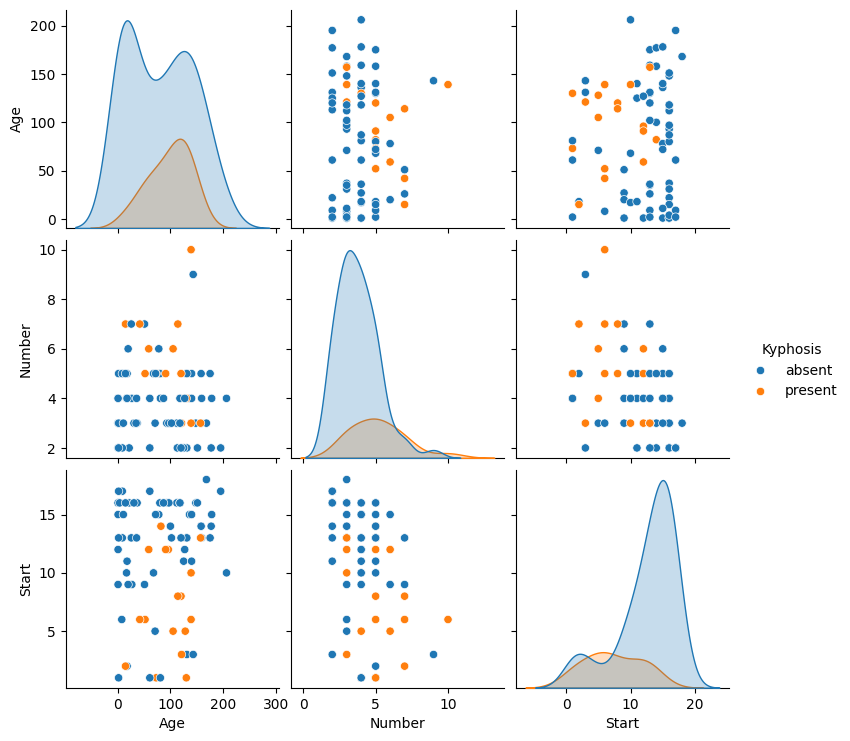

In [8]:
sns.pairplot(df,hue='Kyphosis')

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x=df.drop('Kyphosis',axis=1)
y=df['Kyphosis']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dtree=DecisionTreeClassifier()

In [14]:
dtree.fit(x_train,y_train)

DecisionTreeClassifier()

In [15]:
predictions=dtree.predict(x_test)

In [16]:
from sklearn.metrics import classification_report,confusion_matrix

In [17]:
print(confusion_matrix(y_test,predictions))

[[18  2]
 [ 5  0]]


In [18]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

      absent       0.78      0.90      0.84        20
     present       0.00      0.00      0.00         5

    accuracy                           0.72        25
   macro avg       0.39      0.45      0.42        25
weighted avg       0.63      0.72      0.67        25



In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rfc=RandomForestClassifier(n_estimators=200)

In [21]:
rfc.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [22]:
rfc_pred=rfc.predict(x_test)

In [23]:
print(confusion_matrix(y_test,rfc_pred))
print('\n')
print(classification_report(y_test,rfc_pred))

[[16  4]
 [ 5  0]]


              precision    recall  f1-score   support

      absent       0.76      0.80      0.78        20
     present       0.00      0.00      0.00         5

    accuracy                           0.64        25
   macro avg       0.38      0.40      0.39        25
weighted avg       0.61      0.64      0.62        25



In [24]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

features=list(df.columns[1:])
features

['Age', 'Number', 'Start']

In [25]:
dot_data=StringIO()
export_graphviz(dtree,out_file=dot_data,feature_names=features,filled=True,rounded=True)

graph=pydot.graph_from_dot_data(dot_data.getvalue())

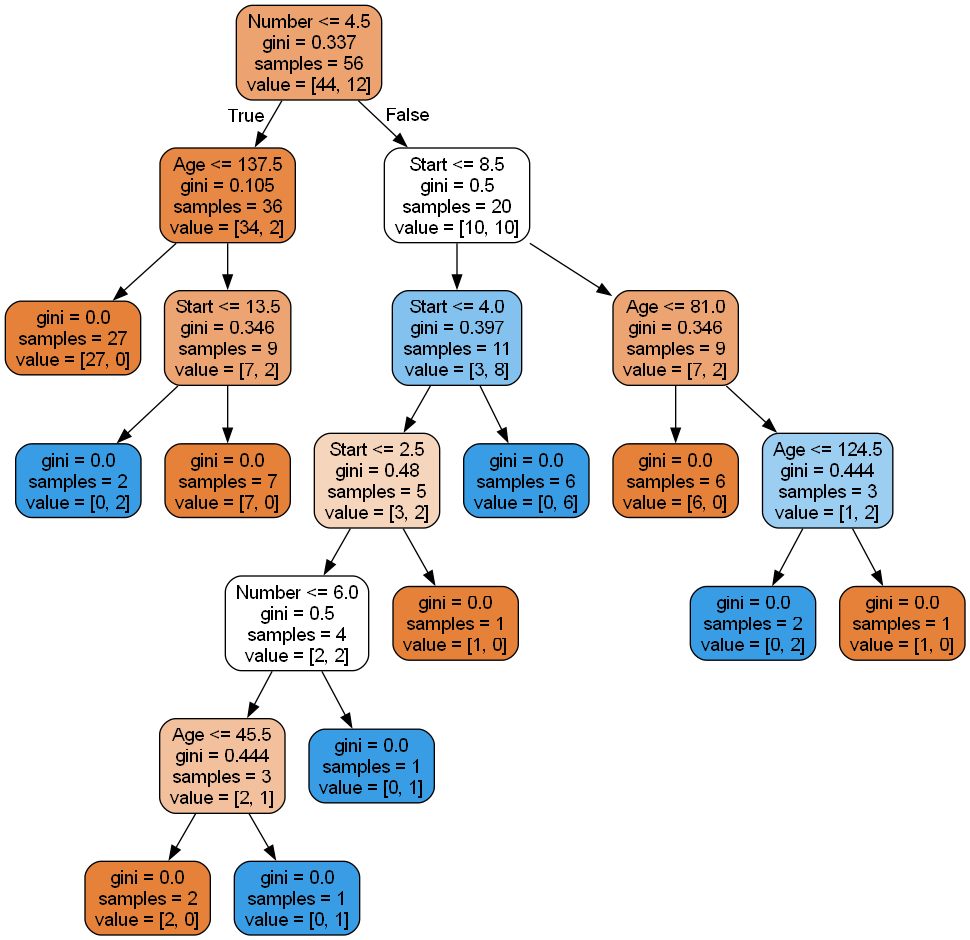

In [26]:
Image(graph[0].create_png())